## Part I: Decision Stump By Hand


## 1.1 Get the data

In [147]:
import os, sys
import pandas as pd
import numpy as np

In [148]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### 1.1.1 Explore

In [149]:
data = pd.read_csv("/content/gdrive/MyDrive/data/intro_ml_2025/ATLAS_higgs_train.csv")

In [150]:
data.shape

(35000, 21)

In [151]:
data.columns

Index(['Z1mass', 'Z2mass', 'detajj', 'massjj', 'l1pdgid', 'l1eta', 'l1phi',
       'l1pt', 'l2pdgid', 'l2eta', 'l2phi', 'l2pt', 'l3pdgid', 'l3eta',
       'l3phi', 'l3pt', 'l4pdgid', 'l4eta', 'l4phi', 'l4pt', 'sample'],
      dtype='object')

In [152]:
data.head(5)

,Z1mass,Z2mass,detajj,massjj,l1pdgid,l1eta,l1phi,l1pt,l2pdgid,l2eta,...,l2pt,l3pdgid,l3eta,l3phi,l3pt,l4pdgid,l4eta,l4phi,l4pt,sample
0,68.515258,57.174385,4.283580,556.406882,-11,0.490221,-2.302279,68.776711,-11,0.910430,...,50.775758,11,-0.495413,-1.409834,28.700672,11,0.542029,-0.328558,17.054512,1
1,84.330551,25.551337,1.101106,266.768190,-11,1.291437,1.917571,77.658719,11,0.142028,...,61.922754,-13,0.208367,1.411837,30.645279,13,1.380638,0.300915,8.034711,-1
2,90.902327,30.404745,2.394863,211.879331,-13,0.702544,-0.946013,91.046750,13,0.958006,...,32.417166,11,0.385190,0.934649,17.942230,-11,0.672241,-1.410558,14.799019,-1
3,91.129112,26.609989,1.040268,56.235126,-11,-2.450392,3.123466,58.988305,11,-1.276226,...,30.001736,-13,-1.275654,0.280533,12.816265,13,-2.283192,-2.326921,11.448904,1
4,87.525977,32.304742,3.674720,351.241850,11,-1.303559,0.963711,66.502133,-11,-0.254885,...,26.519908,-13,-1.052104,0.041387,22.981393,13,0.099710,1.758643,12.038583,1


In [153]:
data.describe()

,Z1mass,Z2mass,detajj,massjj,l1pdgid,l1eta,l1phi,l1pt,l2pdgid,l2eta,...,l2pt,l3pdgid,l3eta,l3phi,l3pt,l4pdgid,l4eta,l4phi,l4pt,sample
count,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,...,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000
mean,82.644232,26.473555,1.714653,185.518419,-0.042057,-0.002688,-0.013040,74.301508,0.045771,0.000866,...,40.346709,0.084743,-0.006417,0.010657,24.622120,-0.088457,0.006155,0.012896,14.221723,0.000000
std,12.531752,10.561741,1.288890,204.113673,11.858642,1.054859,1.807065,37.270313,11.917177,1.075921,...,17.495207,12.019866,1.092094,1.816707,11.481221,12.035518,1.121613,1.816065,6.840068,1.000014
min,13.519004,2.010767,0.000023,11.266586,-13.000000,-2.625673,-3.141397,25.786283,-13.000000,-2.685068,...,9.306786,-13.000000,-2.699203,-3.141561,7.030563,-13.000000,-2.699395,-3.141244,7.000066,-1.000000
25%,77.961392,19.348724,0.579244,58.344373,-11.000000,-0.738641,-1.577672,50.107289,-11.000000,-0.756355,...,29.594369,-11.000000,-0.799920,-1.564671,16.821970,-13.000000,-0.817048,-1.566181,9.490091,-1.000000
50%,87.695827,25.971401,1.422066,112.106252,-11.000000,-0.013663,-0.007000,64.329908,11.000000,-0.001233,...,36.525893,11.000000,-0.011111,0.018410,22.275874,-11.000000,0.018053,0.033467,12.424400,0.000000
75%,90.830151,31.848283,2.731503,234.754944,11.000000,0.749922,1.543869,86.881076,11.000000,0.766395,...,45.956929,11.000000,0.787181,1.581140,29.336642,11.000000,0.815141,1.575925,16.752457,1.000000
max,199.438920,88.834937,4.986040,2869.846840,13.000000,2.699144,3.141420,487.098813,13.000000,2.698684,...,296.474219,13.000000,2.694279,3.141185,146.653828,13.000000,2.698778,3.141072,111.118062,1.000000


In [154]:
data['sample'].value_counts()


,count
sample,
1,17500
-1,17500


### 1.1.2 Visualize the Training Data

In [155]:
# Variables of interest
XNAME = 'detajj'; XLABEL = r'$|\Delta\eta_{jj}|$'
YNAME = 'massjj'; YLABEL = r'$m_{jj}$ (GeV)'

inputs = [XNAME, YNAME]

# Binning ranges
XBINS, XMIN, XMAX, XSTEP = 5, 0, 5, 1
YBINS, YMIN, YMAX, YSTEP = 5, 0, 1000, 200

# Split training data into signal and background
sig = data[data["sample"]==1]
bkg = data[data["sample"]==-1]

In [156]:
import matplotlib.pyplot as plt

FONTSIZE = 16
params = {
         'axes.labelsize': FONTSIZE,
         'axes.titlesize': FONTSIZE,
         'xtick.labelsize':FONTSIZE,
         'ytick.labelsize':FONTSIZE,
         'legend.fontsize':FONTSIZE}
plt.rcParams.update(params)

In [157]:
def plot_scatter(sig, bkg,
              xname=XNAME, xlabel=XLABEL, xmin=XMIN, xmax=XMAX, xstep=XSTEP,
              yname=YNAME, ylabel=YLABEL, ymin=YMIN, ymax=YMAX, ystep=YSTEP,
              fgsize=(6, 6), ftsize=FONTSIZE, alpha=0.3, title="Scatter plot"):

  fig, ax = plt.subplots(figsize=fgsize)

  # Annotate x-axis
  ax.set_xlim(xmin, xmax)
  ax.set_xlabel(xlabel)
  ax.set_xticks(np.arange(xmin, xmax+xstep, xstep))

  # Annotate y-axis
  ax.set_ylim(ymin, ymax)
  ax.set_ylabel(ylabel)
  ax.set_yticks(np.arange(ymin, ymax+ystep, ystep))

  # Scatter signal and background:
  ax.scatter(sig[xname], sig[yname], marker='o', s=8, c='b', alpha=alpha, label='VBF')
  ax.scatter(bkg[xname], bkg[yname], marker='*', s=8, c='r', alpha=alpha, label='ggf')

  # Legend and plot:
  ax.legend(fontsize=ftsize, bbox_to_anchor=(1.04, 0.5), loc="center left", frameon=False)
  ax.set_title(title, pad=20)
  plt.show()

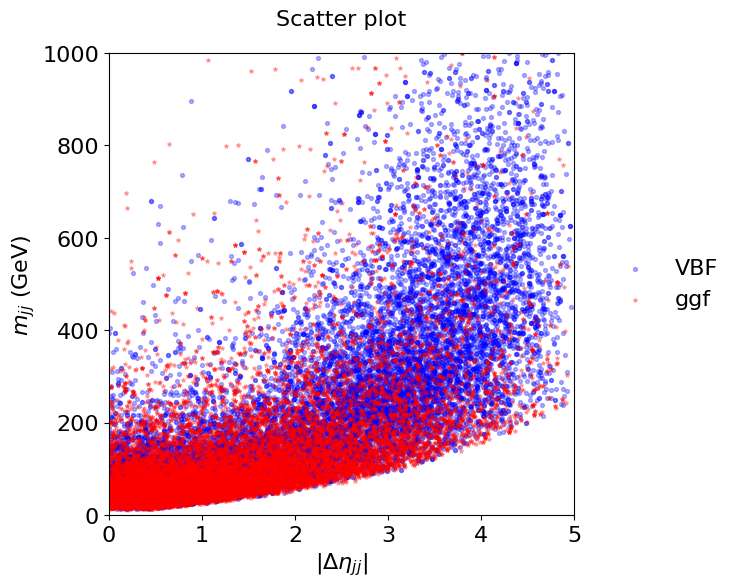

In [158]:
plot_scatter(sig, bkg)

In [159]:
# Extract detajj & massjj and convert to NumPy
X_train = data[['detajj','massjj']].to_numpy()
y_train = data['sample'].to_numpy()

## 1.2 Compute the Gini Index

In [160]:
def get_gini_index(y, classes):
    """
    y       : NumPy array of labels in the node
    classes : list of possible class values (e.g., [-1, 1])
    """
    # verify size of y
    sum = 1
    m = len(y)
    if m == 0:
      return 0
    else:
      for classe in classes:
          sum -= (np.sum(y==classe)/m)**2
      return sum

## 1.3 Compute the Cost Function

$$
J(j, t_j) = \frac{N_\text{left}}{N_\text{node}} G_\text{left} + \frac{N_\text{right}}{N_\text{node}} G_\text{right} \;
$$


In [161]:
def get_cost(n_left, gini_left, n_right, gini_right):
    """
    let's write the docstring
    """
    n_node = n_left + n_right
    left_term = (n_left/n_node)*gini_left
    right_term = (n_right/n_node)*gini_right
    return left_term + right_term

## 1.4 Decision Stump: Core of the Action

In [162]:
def get_threshold_min_cost(feature_values, y, classes, precision=0.01):
    """
    Find the threshold that minimizes the weighted Gini index.
    """
    ## Verify y and feature_values lenght
    #initialisation
    optmal_threshold = np.inf
    cost_min = np.inf
    # Take unique values of feature_values
    unique_values = np.unique(feature_values)
    step = (max(unique_values) - min(unique_values))*precision
    for value in np.arange(min(unique_values),max(unique_values),step):
        #split left and right
        y_left = y[feature_values > value]
        gini_left = get_gini_index(y_left, classes)
        y_right = y[feature_values <= value]
        gini_right = get_gini_index(y_right, classes)
        #Calculate cost
        cost = get_cost(len(y_left), gini_left, len(y_right), gini_right)
        if cost_min > cost :
          cost_min = cost
          optmal_threshold = value
    return optmal_threshold,cost_min


## 1.5 The Best Split

In [163]:
feature_values_detajj = X_train[:,0]
feature_values_mjj = X_train[:,1]
classes = np.unique(y_train)
optmal_threshold_detajj,cost_min_detajj= get_threshold_min_cost(feature_values_detajj, y_train, classes, precision=0.01)
optmal_threshold_mjj,cost_min_mjj= get_threshold_min_cost(feature_values_mjj, y_train, classes, precision=0.01)

In [164]:
print(f"The best split of Mjj is :{optmal_threshold_mjj} with the cost:{cost_min_mjj}")
print(f"The best split of Detajj is :{optmal_threshold_detajj} with the cost:{cost_min_detajj}")

The best split of Mjj is :211.36720405702897 with the cost:0.4564653274962664
The best split of Detajj is :2.5428917470574377 with the cost:0.4660251041567094


## 1.6 Plot the Cut

In [165]:
def plot_scatter(sig, bkg,
              xname=XNAME, xlabel=XLABEL, xmin=XMIN, xmax=XMAX, xstep=XSTEP,
              yname=YNAME, ylabel=YLABEL, ymin=YMIN, ymax=YMAX, ystep=YSTEP,
              fgsize=(6, 6), ftsize=FONTSIZE, alpha=0.3, title="Scatter plot"):

  fig, ax = plt.subplots(figsize=fgsize)

  ax.axhline(y=optmal_threshold_mjj, xmin=xmin, xmax=xmax,c ='g',label='optmal_threshold_mjj')
  ax.axvline(x=optmal_threshold_detajj, ymin=ymin, ymax=ymax,c ='y',label='optmal_threshold_detajj')
  # Annotate x-axis
  ax.set_xlim(xmin, xmax)
  ax.set_xlabel(xlabel)
  ax.set_xticks(np.arange(xmin, xmax+xstep, xstep))

  # Annotate y-axis
  ax.set_ylim(ymin, ymax)
  ax.set_ylabel(ylabel)
  ax.set_yticks(np.arange(ymin, ymax+ystep, ystep))

  # Scatter signal and background:
  ax.scatter(sig[xname], sig[yname], marker='o', s=8, c='b', alpha=alpha, label='VBF')
  ax.scatter(bkg[xname], bkg[yname], marker='*', s=8, c='r', alpha=alpha, label='ggf')

  # Legend and plot:
  ax.legend(fontsize=ftsize, bbox_to_anchor=(1.04, 0.5), loc="center left", frameon=False)
  ax.set_title(title, pad=20)
  plt.show()

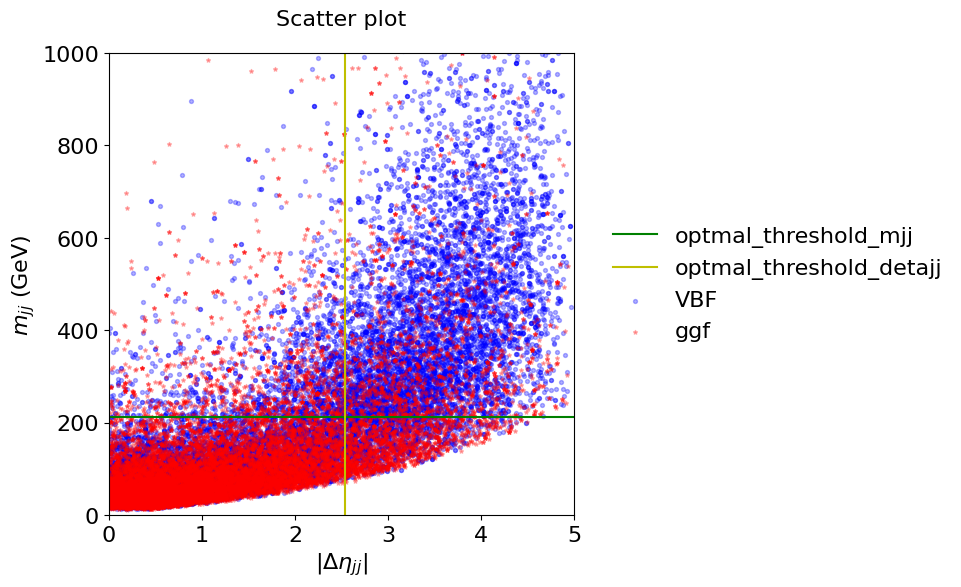

In [166]:
plot_scatter(sig, bkg)